Setup

In [356]:
import heapq
import random
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

In [357]:
# Using these same values everywhere, to keep consistency between plots and animations
EMPTY = 0
WALL = -1
ITEM = 2
ITEM_PICKED = 1.2
START = 2.2
AGENT = 3

CMAP = "GnBu"

Grid layout

In [358]:
# Grid Size
grid_width = 42
grid_height = 42

grid = [[0 for _ in range(grid_width)] for _ in range(grid_height)]

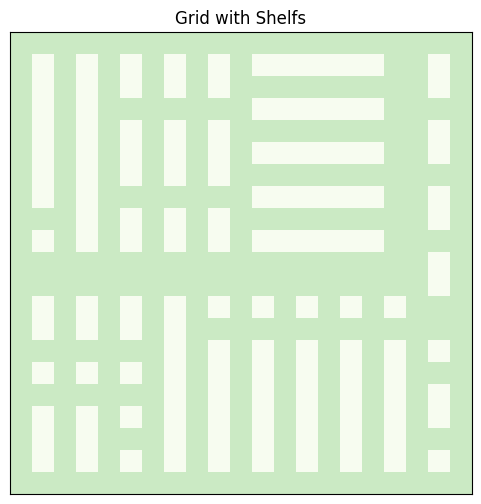

In [359]:
# Function to add a shelf to the grid
def add_shelf(grid, top_left, bottom_right):
    x1, y1 = top_left
    x2, y2 = bottom_right
    
    for y in range(y1, y2):
        for x in range(x1, x2):
            grid[y][x] = 1


# Function where we create our layout with all our shelfs            
def create_store_layout(grid):
    add_shelf(grid, (2, 2), (4, 16))
    add_shelf(grid, (2, 18), (4, 20))
    add_shelf(grid, (6, 2), (8, 20))
    add_shelf(grid, (10, 2), (12, 6))
    add_shelf(grid, (10, 8), (12, 14))
    add_shelf(grid, (10, 16), (12, 20))
    add_shelf(grid, (14, 2), (16, 6))
    add_shelf(grid, (14, 8), (16, 14))
    add_shelf(grid, (14, 16), (16, 20))
    add_shelf(grid, (18, 2), (20, 6))
    add_shelf(grid, (18, 8), (20, 14))
    add_shelf(grid, (18, 16), (20, 20))
    add_shelf(grid, (22, 2), (34, 4))
    add_shelf(grid, (22, 6), (34, 8))
    add_shelf(grid, (22, 10), (34, 12))
    add_shelf(grid, (22, 14), (34, 16))
    add_shelf(grid, (22, 18), (34, 20))
    add_shelf(grid, (38, 2), (40, 6))
    add_shelf(grid, (38, 8), (40, 12))
    add_shelf(grid, (38, 14), (40, 18))
    add_shelf(grid, (38, 20), (40, 24)) 
    add_shelf(grid, (38, 28), (40, 30))
    add_shelf(grid, (38, 32), (40, 36))
    add_shelf(grid, (38, 38), (40, 40))
    add_shelf(grid, (2, 24), (4, 28))
    add_shelf(grid, (2, 30), (4, 32)) 
    add_shelf(grid, (2, 34), (4, 40))
    add_shelf(grid, (6, 24), (8, 28))
    add_shelf(grid, (6, 30), (8, 32)) 
    add_shelf(grid, (6, 34), (8, 40))
    add_shelf(grid, (10, 24), (12, 28))
    add_shelf(grid, (10, 30), (12, 32)) 
    add_shelf(grid, (10, 34), (12, 36))
    add_shelf(grid, (10, 38), (12, 40))
    add_shelf(grid, (14, 24), (16, 40))
    add_shelf(grid, (18, 24), (20, 26))
    add_shelf(grid, (18, 28), (20, 40))
    add_shelf(grid, (22, 24), (24, 26))
    add_shelf(grid, (22, 28), (24, 40))
    add_shelf(grid, (26, 24), (28, 26))
    add_shelf(grid, (26, 28), (28, 40))
    add_shelf(grid, (30, 24), (32, 26))
    add_shelf(grid, (30, 28), (32, 40))
    add_shelf(grid, (34, 24), (36, 26))
    add_shelf(grid, (34, 28), (36, 40))


# Running the function
create_store_layout(grid)


# Function to visualize the grid with shelfs
def visualizeItems_matplotlib(grid):
    height = len(grid)
    width = len(grid[0])
    
    # numeric grid
    heat = np.full((height, width), EMPTY, dtype=float)
    
    # shelves
    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                heat[y][x] = WALL   # walls
    
    
    # plot
    plt.figure(figsize=(6,6))
    plt.imshow(heat, cmap = CMAP, vmin=-1, vmax=3)
    plt.title("Grid with Shelfs")
    plt.xticks([])
    plt.yticks([])
    plt.show()


# Running the function
visualizeItems_matplotlib(grid)

Item/start creation and placement

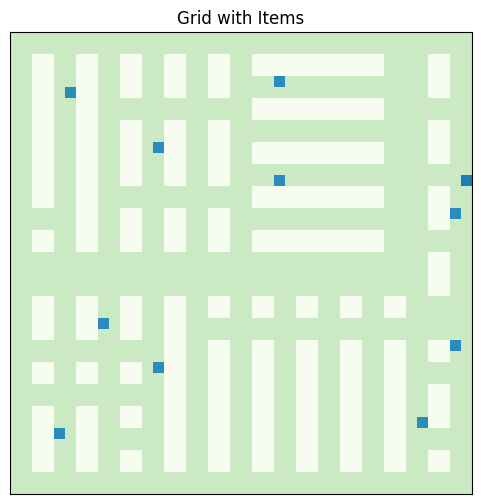

In [360]:
# The agents start position
start = (41, 13)

# Each item location on the grid
items = [
    #(9, 2),
    (13, 10),
    #(37, 9),
    (40, 16),
    #(30, 20),
    (4, 36),
    #(8, 35),
    (13, 30),
    #(20, 31),
    (37, 35),
    #(20, 24),
    (24, 4),
    #(33, 1),
    (5, 5),
    #(20, 18),
    (8, 26),
    #(32, 37),
    (40, 28),
    #(16, 27),
    (24, 13)
]


# Function to visualise the grid with shelfs, items, and start position
def visualizeItems_matplotlib(grid, start, items):
    height = len(grid)
    width = len(grid[0])
    
    # numeric grid
    heat = np.full((height, width), EMPTY, dtype=float)
    
    # shelves
    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                heat[y][x] = WALL   # walls
    
    # items
    for (x, y) in items:
        if EMPTY <= x < width and EMPTY <= y < height:
            heat[y][x] = ITEM
    
    # start
    sx, sy = start
    if EMPTY <= sx < width and EMPTY <= sy < height:
        heat[sy][sx] = START
    
    # plot
    plt.figure(figsize=(6,6))
    plt.imshow(heat, cmap=CMAP, vmin=-1, vmax=3)
    plt.title("Grid with Items")
    plt.xticks([])
    plt.yticks([])
    plt.show()


# Running the function
visualizeItems_matplotlib(grid, start, items)

A* Pathfinding

In [361]:
# ????
def get_neighbors(pos):
    x, y = pos
    
    candidates = [
        (x+1, y),
        (x-1, y),
        (x, y+1),
        (x, y-1)
    ]
    
    valid = []
    for nx, ny in candidates:
        if 0 <= nx < grid_width and 0 <= ny < grid_height:
            valid.append((nx, ny))
    
    return valid

# ????
def heuristic(a, b):
    ax, ay = a
    bx, by = b
    return abs(ax - bx) + abs(ay - by)

In [362]:
# A* for distance (used by GA)
def astar_distance(grid, start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))
    
    g_score = {start: 0}
    
    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == goal:
            return g_score[current]   # ✅ ONLY number
        
        for neighbor in get_neighbors(current):
            x, y = neighbor
            
            if not (0 <= x < len(grid[0]) and 0 <= y < len(grid)):
                continue
            if grid[y][x] == 1:
                continue
            
            tentative = g_score[current] + 1
            
            if neighbor not in g_score or tentative < g_score[neighbor]:
                g_score[neighbor] = tentative
                f = tentative + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor))
    
    return float("inf")  # unreachable

In [363]:
# A* for full path (used for animation)
def astar_path(grid, start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))
    
    came_from = {}
    g_score = {start: 0}
    
    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == goal:
            # reconstruct path
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            return path
        
        for neighbor in get_neighbors(current):
            x, y = neighbor
            
            if not (0 <= x < len(grid[0]) and 0 <= y < len(grid)):
                continue
            if grid[y][x] == 1:
                continue
            
            tentative = g_score[current] + 1
            
            if neighbor not in g_score or tentative < g_score[neighbor]:
                g_score[neighbor] = tentative
                came_from[neighbor] = current
                f = tentative + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor))
    
    return []

In [364]:
points = [start] + items
distance_matrix = {}

for i in range(len(points)):
    for j in range(len(points)):
        if i != j:
            distance_matrix[(i, j)] = astar_distance(
                grid, points[i], points[j]
            )

Genetic Algorithm

Godt link til Genetic Algorithms
https://www.tutorialspoint.com/genetic_algorithms/genetic_algorithms_crossover.htm

In [365]:
#import random
NUM_ITEMS = len(items)

In [366]:
def create_population(size):
    population = []
    base = list(range(NUM_ITEMS))
    
    for _ in range(size):
        individual = base[:]
        random.shuffle(individual)
        population.append(individual)
    
    return population

In [367]:
def route_distance(route):
    total = 0
    
    # start → first item
    total += distance_matrix[(0, route[0]+1)]
    
    # between items
    for i in range(len(route)-1):
        total += distance_matrix[(route[i]+1, route[i+1]+1)]
    
    # last item → back to start
    total += distance_matrix[(route[-1]+1, 0)]
    
    return total

In [409]:
# Parent Selection Types: Random, Tournament, Roulette, Rank, SUS

def random_sel(pop): return random.choice(pop)

def tournament_sel(pop):
    return min(random.sample(pop,3), key=route_distance)

def roulette_sel(pop):
    w=[1/(route_distance(p)+1) for p in pop]
    return random.choices(pop,weights=w)[0]

def rank_sel(pop):
    s=sorted(pop,key=route_distance)
    w=list(range(1,len(pop)+1))
    return random.choices(s,weights=w)[0]

def sus_sel(pop):
    w=[1/(route_distance(p)+1) for p in pop]
    total=sum(w)
    pick=random.uniform(0,total)
    cur=0
    for i,p in enumerate(pop):
        cur+=w[i]
        if cur>pick: return p


#Choosing which selection type we want to use
SELECTION="tournament"

def select(pop):
    if SELECTION=="random": return random_sel(pop)
    if SELECTION=="roulette": return roulette_sel(pop)
    if SELECTION=="sus": return sus_sel(pop)
    if SELECTION=="rank": return rank_sel(pop)
    return tournament_sel(pop)

In [370]:
def crossover(p1, p2):
    start, end = sorted(random.sample(range(NUM_ITEMS), 2))
    child = [None]*NUM_ITEMS
    
    child[start:end] = p1[start:end]
    
    fill = [x for x in p2 if x not in child]
    
    idx = 0
    for i in range(NUM_ITEMS):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    
    return child

In [371]:
def mutate(route, rate=0.02):
    if random.random() < rate:
        i, j = random.sample(range(NUM_ITEMS), 2)
        route[i], route[j] = route[j], route[i]
    return route

In [418]:
def genetic_algorithm(generations=200, size=5000):
    pop = create_population(size)
    
    best = min(pop, key=route_distance)
    
    for g in range(generations):
        new_pop = []
        
        for _ in range(size):
            p1 = select(pop)
            p2 = select(pop)
            
            child = crossover(p1, p2)
            child = mutate(child)
            
            new_pop.append(child)
        
        population = new_pop
        
        current = min(population, key=route_distance)
        if route_distance(current) < route_distance(best):
            best = current
        
        if g % 20 == 0:
            print(f"Gen {g}: {route_distance(best)}")
    
    return best

In [421]:
best_route = genetic_algorithm()

print("Best route:", best_route)
print("Distance:", route_distance(best_route))

Gen 0: 210
Gen 20: 188
Gen 40: 188
Gen 60: 186
Gen 80: 186
Gen 100: 186
Gen 120: 186
Gen 140: 186
Gen 160: 186
Gen 180: 186
Best route: [1, 8, 4, 2, 3, 7, 6, 0, 5, 9]
Distance: 186


In [374]:
def build_full_path(route):
    full_path = []
    
    current = start
    
    for idx in route:
        target = items[idx]
        path_segment = astar_path(grid, current, target)
        
        if full_path:
            path_segment = path_segment[1:]  # avoid duplicates
        
        full_path.extend(path_segment)
        current = target
    
    # optional: return to start
    path_back = astar_path(grid, current, start)
    full_path.extend(path_back[1:])
    
    return full_path

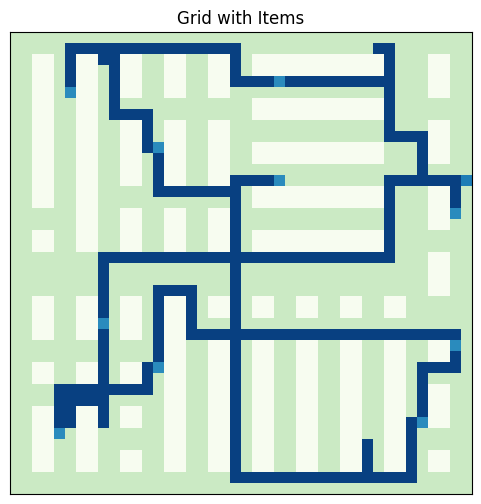

In [375]:
# Function to visualise the grid with shelfs, items, and start position
def visualizeItems_matplotlib(grid, full_path, start, items):
    height = len(grid)
    width = len(grid[0])
    
    # numeric grid
    heat = np.full((height, width), EMPTY, dtype=float)
    
    # shelves
    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                heat[y][x] = WALL   # walls
    
    # items
    for (x, y) in items:
        if EMPTY <= x < width and EMPTY <= y < height:
            heat[y][x] = ITEM
    
    # start
    sx, sy = start
    if EMPTY <= sx < width and EMPTY <= sy < height:
        heat[sy][sx] = START

    # path
    for (x, y) in full_path:
        if EMPTY <= x < width and EMPTY <= y < height:
            if (x, y) != start and (x, y) not in items:
                heat[y][x] = AGENT
    
    # plot
    plt.figure(figsize=(6,6))
    plt.imshow(heat, cmap=CMAP, vmin=-1, vmax=3)
    plt.title("Grid with Items")
    plt.xticks([])
    plt.yticks([])
    plt.show()


# Running the function
visualizeItems_matplotlib(grid, full_path, start, items)

In [376]:


def animate_heatmap(grid, path, start, items, trail_length=10, delay=0.15):

    height = len(grid)
    width = len(grid[0])
    
    trail = []
    visited_items = set()
    
    item_set = set(items)  # faster lookup
    
    for step in range(len(path)):
        current = path[step]
        trail.append(current)
        
        if len(trail) > trail_length:
            trail.pop(0)
        
        # mark item as visited if reached
        if current in item_set:
            visited_items.add(current)
        
        heat = np.full((height, width), EMPTY, dtype=float)
        
        # 1. walls
        for y in range(height):
            for x in range(width):
                if grid[y][x] == 1:
                    heat[y][x] = WALL
        
        # 2. fading trail (FIXED)
        trail_heat = np.zeros((height, width))

        for i, (x, y) in enumerate(trail):
            intensity = (i + 1) / len(trail)
            trail_heat[y][x] = intensity

        heat += trail_heat * 2.0
        
        # 3. items (NOT visited yet → red-ish)
        for (x, y) in items:
            if (x, y) in visited_items:
                heat[y][x] = ITEM_PICKED   # collected item (faded)
            else:
                heat[y][x] = ITEM   # unvisited item (bright)
        
        # 4. agent
        x, y = current
        heat[y][x] = AGENT
        
        # 5. start
        sx, sy = start
        heat[sy][sx] = START
        
        # plot
        clear_output(wait=True)
        plt.figure(figsize=(6, 6))
        
        plt.imshow(heat, cmap=CMAP, vmin=-1, vmax=3)
        plt.title(f"Step {step+1}/{len(path)} | Collected: {len(visited_items)}/{len(items)}")
        
        plt.xticks([])
        plt.yticks([])
        
        plt.show()
        
        time.sleep(delay)

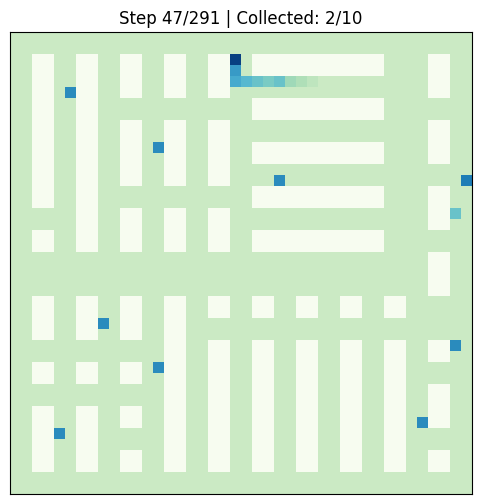

KeyboardInterrupt: 

In [377]:
animate_heatmap(grid, full_path, start, items)

In [ ]:
def genetic_algorithm_with_history(generations=100, size=100):
    population = create_population(size)
    
    history = []  # store best route per generation
    
    best = min(population, key=route_distance)
    
    for g in range(generations):
        new_pop = []
        
        for _ in range(size):
            p1 = selection(population)
            p2 = selection(population)
            
            child = crossover(p1, p2)
            child = mutate(child)
            
            new_pop.append(child)
        
        population = new_pop
        
        current = min(population, key=route_distance)
        
        if route_distance(current) < route_distance(best):
            best = current
        
        history.append(best.copy())  # store snapshot
        
        if g % 10 == 0:
            print(f"Gen {g}: {route_distance(best)}")
    
    return history

In [ ]:
history = genetic_algorithm_with_history()

Gen 0: 476
Gen 10: 374
Gen 20: 306
Gen 30: 286
Gen 40: 280
Gen 50: 280
Gen 60: 280
Gen 70: 280
Gen 80: 280
Gen 90: 272


In [ ]:
def animate_ga_heatmap(grid, history, start, items, delay=0.3):
    height = len(grid)
    width = len(grid[0])
    
    for gen, route in enumerate(history):
        
        full_path = build_full_path(route)
        
        heat = np.full((height, width), EMPTY, dtype=float)
        
        # 1. walls
        for y in range(height):
            for x in range(width):
                if grid[y][x] == 1:
                    heat[y][x] = WALL
        
        # 2. path intensity (visitation frequency)
        for (x, y) in full_path:
            heat[y][x] += 0.5
        
        # 3. items (highlight)
        for (x, y) in items:
            heat[y][x] = 2
        
        # 4. start
        sx, sy = start
        heat[sy][sx] = 2.5
        
        # plot frame
        clear_output(wait=True)
        plt.figure(figsize=(6, 6))
        
        plt.imshow(heat, cmap=CMAP)
        # plt.colorbar(label="Intensity")
        
        plt.title(f"GA Evolution - Generation {gen}")
        plt.xticks([])
        plt.yticks([])
        
        plt.show()
        
        time.sleep(delay)

In [ ]:
animate_ga_heatmap(grid, history, start, items)

KeyboardInterrupt: 

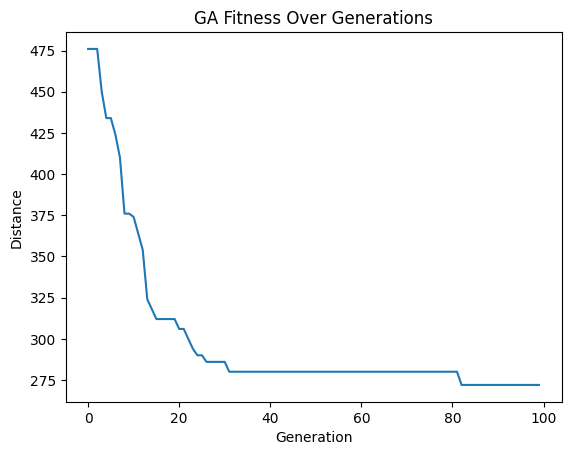

In [ ]:
#import matplotlib.pyplot as plt

fitness = [route_distance(r) for r in history]

plt.plot(fitness)
plt.title("GA Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Distance")
plt.show()